In [1]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 33.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from multiprocessing import Pool
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
import faiss
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
from sklearn.metrics import adjusted_rand_score

In [3]:
PCA_rule_of_thumb=pd.read_csv('PCA_rule_of_thumb.csv')
PCA_kaiser=pd.read_csv('PCA_kaiser.csv')
PCA_parallel=pd.read_csv('PCA_parallel.csv')
UMAP_euclidean=pd.read_csv('UMAP_euclidean.csv')
UMAP_cosine=pd.read_csv('UMAP_cosine.csv')
UMAP_clustering=pd.read_csv('UMAP_clu.csv')

In [6]:
UMAP_clustering['original_labels'] = UMAP_clustering['cluster']
UMAP_clustering=UMAP_clustering.drop(columns=['cluster'])

In [ ]:
# Define the range for the number of clusters to test CHIAMA TUTTE LE COL UGUALI E RIPROVA
cluster_ranges = range(2, 31)

# List of datasets (DataFrames) and their corresponding method names
datasets = [
    ("PCA_rule_of_thumb", PCA_rule_of_thumb),
    ("PCA_kaiser", PCA_kaiser),
    ("PCA_parallel", PCA_parallel),
    ("UMAP_euclidean", UMAP_euclidean),
    ("UMAP_cosine", UMAP_cosine),
    ("UMAP_highdim", UMAP_highdim)
]

# Function to perform KMeans clustering and return results DataFrame
def perform_kmeans_clustering(method_data_pair):
    method_name, df = method_data_pair
    features = df.drop(columns=['user_uid','original_labels'])

    results = []
    # Loop over the number of clusters for KMeans
    for n_clusters in cluster_ranges:
        # Apply KMeans clustering
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        cluster_labels = kmeans.fit_predict(features)

        # Calculate the within-cluster sum of squares (inertia)
        inertia = kmeans.inertia_

        # Calculate the silhouette score
        silhouette_avg = silhouette_score(features, cluster_labels)

        # Store the result
        results.append((n_clusters, inertia, silhouette_avg, method_name))

    # Convert results to a DataFrame for analysis
    results_df = pd.DataFrame(results, columns=['n_clusters', 'inertia', 'silhouette_score', 'method'])
    return results_df

# Function to handle parallel processing of datasets
def process_datasets_in_parallel(datasets, num_workers=4):
    with Pool(num_workers) as pool:
        all_results = pool.map(perform_kmeans_clustering, datasets)
    return all_results

# Process datasets in parallel
all_results = process_datasets_in_parallel(datasets)

# Concatenate all DataFrames into a single DataFrame
all_results_df = pd.concat(all_results, ignore_index=True)

# Display the combined results
print(all_results_df)

# Save the combined results to a CSV file with the updated name
all_results_df.to_csv('euclidean_kmeans.csv', index=False)


     n_clusters       inertia  silhouette_score             method
0             2  2.196347e+07          0.261369  PCA_rule_of_thumb
1             3  2.118356e+07          0.222235  PCA_rule_of_thumb
2             4  2.069120e+07          0.062013  PCA_rule_of_thumb
3             5  2.012521e+07          0.054361  PCA_rule_of_thumb
4             6  1.979054e+07          0.049078  PCA_rule_of_thumb
..          ...           ...               ...                ...
169          26  5.524314e+04          0.380227       UMAP_highdim
170          27  5.253683e+04          0.386300       UMAP_highdim
171          28  5.051798e+04          0.388567       UMAP_highdim
172          29  4.945764e+04          0.387695       UMAP_highdim
173          30  4.786873e+04          0.378378       UMAP_highdim

[174 rows x 4 columns]


In [ ]:
all_results_df.head()

,n_clusters,inertia,silhouette_score,method
0,2,2.196347e+07,0.261369,PCA_rule_of_thumb
1,3,2.118356e+07,0.222235,PCA_rule_of_thumb
2,4,2.069120e+07,0.062013,PCA_rule_of_thumb
3,5,2.012521e+07,0.054361,PCA_rule_of_thumb
4,6,1.979054e+07,0.049078,PCA_rule_of_thumb


In [8]:
# Using faiss library to use cosine distance in K-Means on UMAP with cosine metric

# Define the range for the number of clusters to test
cluster_ranges = range(2, 31)

# List of datasets (DataFrames) and their corresponding method names
datasets = [
    ("PCA_rule_of_thumb", PCA_rule_of_thumb),
    ("PCA_kaiser", PCA_kaiser),
    ("PCA_parallel", PCA_parallel),
    ("UMAP_euclidean", UMAP_euclidean),
    ("UMAP_cosine", UMAP_cosine),
    ("UMAP_clustering", UMAP_clustering)
]

# Function to perform KMeans clustering using Faiss with cosine distance
def perform_faiss_kmeans_clustering(method_data_pair):
    method_name, df = method_data_pair
    features = df.drop(columns=['user_uid','original_labels'])

    # Normalize features to unit length (cosine distance equivalent)
    features_normalized = normalize(features, norm='l2', axis=1)

    results = []
    # Loop over the number of clusters for KMeans
    for n_clusters in cluster_ranges:
        # Initialize Faiss KMeans with cosine distance
        d = features_normalized.shape[1]
        kmeans = faiss.Kmeans(d=d, k=n_clusters, niter=20, spherical=True, seed=42)

        # Train Faiss KMeans
        kmeans.train(features_normalized)
        D, cluster_labels = kmeans.index.search(features_normalized, 1)  # Cluster assignments

        # Calculate the within-cluster sum of squares (inertia) as sum of distances to centroids
        #inertia = np.sum(D) Inertia cannot be used when using cosine distance as metric

        # Calculate the silhouette score
        silhouette_avg = silhouette_score(features_normalized, cluster_labels.ravel())

        # Store the result
        results.append((n_clusters, silhouette_avg, method_name))

    # Convert results to a DataFrame for analysis
    results_df = pd.DataFrame(results, columns=['n_clusters', 'silhouette_score', 'method'])
    return results_df

# Function to handle parallel processing of datasets
def process_datasets_in_parallel(datasets, num_workers=4):
    with Pool(num_workers) as pool:
        all_results = pool.map(perform_faiss_kmeans_clustering, datasets)
    return all_results

# Process datasets in parallel
all_results = process_datasets_in_parallel(datasets)

# Concatenate all DataFrames into a single DataFrame
all_results_faiss_df = pd.concat(all_results, ignore_index=True)

all_results_faiss_df.to_csv('cosine_kmeans.csv', index=False)

In [ ]:
all_results_df =pd.read_csv('euclidean_kmeans.csv')
all_results_faiss_df =pd.read_csv('cosine_kmeans.csv')

In [ ]:
all_results_faiss_df.head()

,n_clusters,silhouette_score,method
0,2,0.079038,PCA_rule_of_thumb
1,3,0.060058,PCA_rule_of_thumb
2,4,0.074685,PCA_rule_of_thumb
3,5,0.078912,PCA_rule_of_thumb
4,6,0.082803,PCA_rule_of_thumb


In [ ]:
# Define a consistent color palette based on all unique methods
methods = all_results_df['method'].unique()
palette = sns.color_palette("tab10", len(methods))  # Use 'tab10', or any other palette
color_dict = dict(zip(methods, palette))

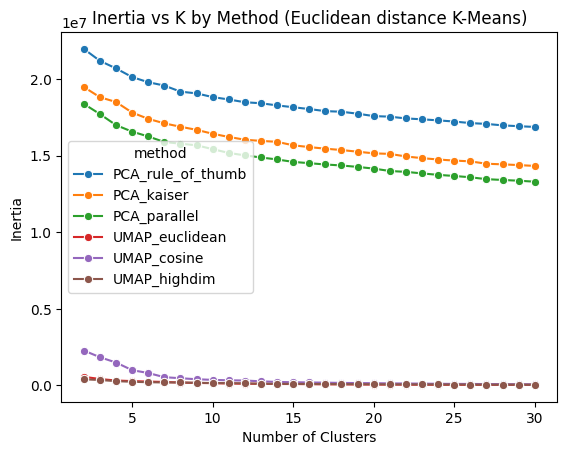

In [ ]:
# Create the line plot
sns.lineplot(all_results_df, x="n_clusters", y="inertia", hue="method", marker="o", palette=color_dict)

# Add labels and title
plt.title("Inertia vs K by Method (Euclidean distance K-Means)")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

# Display the plot
plt.show()

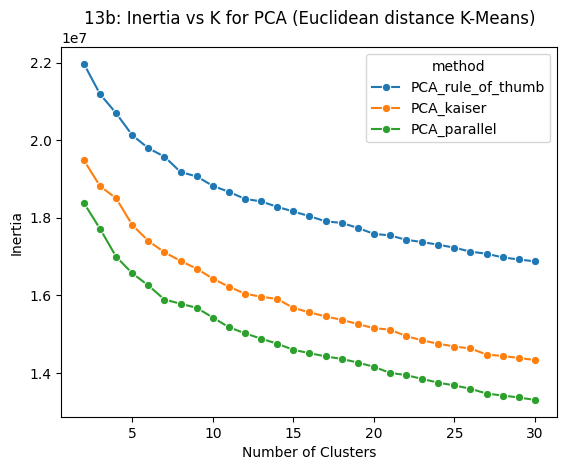

In [ ]:
# CONSISTENZA NEI COLORI!!!
filtered_df = all_results_df[all_results_df['method'].str.contains('PCA', case=False, na=False)]
# Create the line plot
sns.lineplot(filtered_df, x="n_clusters", y="inertia", hue="method", marker="o", palette=color_dict)

# Add labels and title
plt.title("13b: Inertia vs K for PCA (Euclidean distance K-Means)")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

# Display the plot
plt.show()

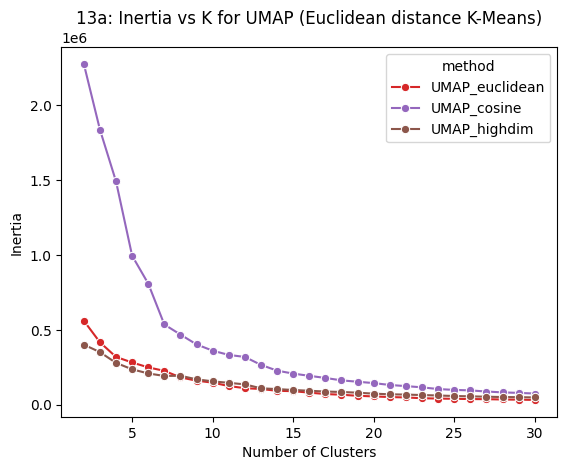

In [ ]:
# CONSISTENZA NEI COLORI!!!
filtered_df = all_results_df[all_results_df['method'].str.contains('UMAP', case=False, na=False)]
# Create the line plot
sns.lineplot(filtered_df, x="n_clusters", y="inertia", hue="method", marker="o", palette=color_dict)

# Add labels and title
plt.title("13a: Inertia vs K for UMAP (Euclidean distance K-Means)")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

# Display the plot
plt.show()

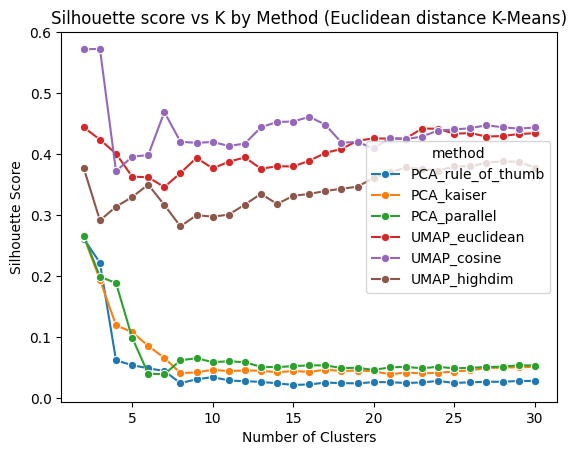

In [ ]:
# Create the line plot
sns.lineplot(all_results_df, x="n_clusters", y="silhouette_score", hue="method", marker="o", palette=color_dict)

# Add labels and title
plt.title("Silhouette score vs K by Method (Euclidean distance K-Means)")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

# Display the plot
plt.show()

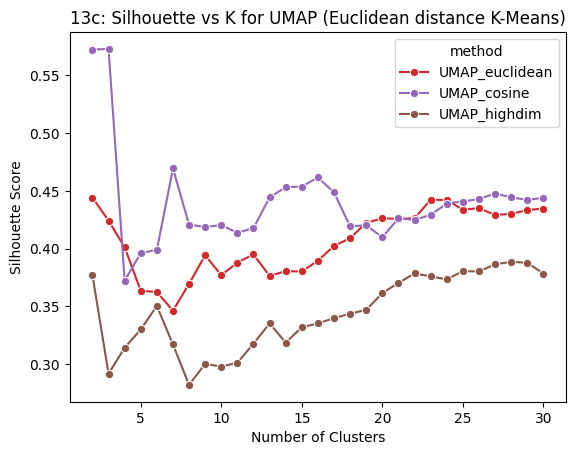

In [ ]:
# CONSISTENZA NEI COLORI!!!
filtered_df = all_results_df[all_results_df['method'].str.contains('UMAP', case=False, na=False)]
# Create the line plot
sns.lineplot(filtered_df, x="n_clusters", y="silhouette_score", hue="method", marker="o", palette=color_dict)

# Add labels and title
plt.title("13c: Silhouette vs K for UMAP (Euclidean distance K-Means)")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

# Display the plot
plt.show()

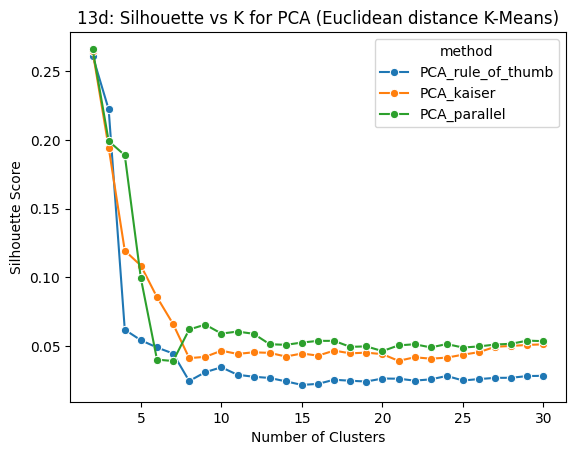

In [ ]:
# CONSISTENZA NEI COLORI!!!
filtered_df = all_results_df[all_results_df['method'].str.contains('PCA', case=False, na=False)]
# Create the line plot
sns.lineplot(filtered_df, x="n_clusters", y="silhouette_score", hue="method", marker="o", palette=color_dict)

# Add labels and title
plt.title("13d: Silhouette vs K for PCA (Euclidean distance K-Means)")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

# Display the plot
plt.show()

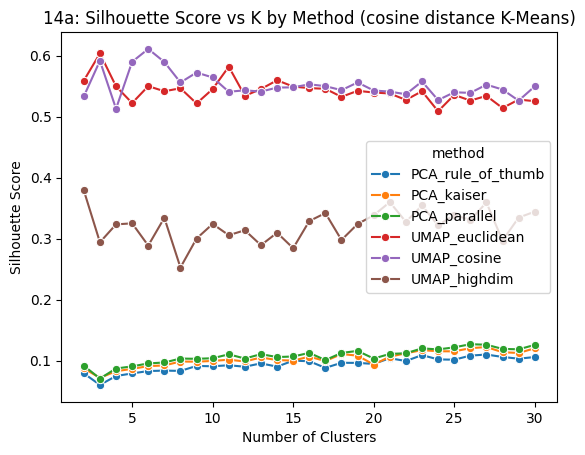

In [ ]:
# Create the line plot
sns.lineplot(all_results_faiss_df, x="n_clusters", y="silhouette_score", hue="method", marker="o", palette=color_dict)

# Add labels and title
plt.title("14a: Silhouette Score vs K by Method (cosine distance K-Means)")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

# Display the plot
plt.show()

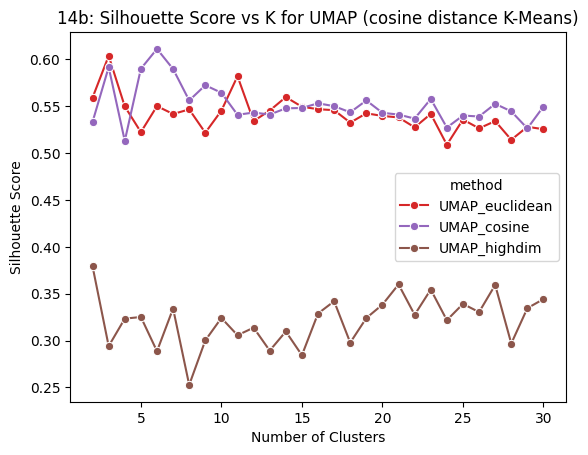

In [ ]:
# CONSISTENZA NEI COLORI!!!
filtered_df = all_results_faiss_df[all_results_faiss_df['method'].str.contains('UMAP', case=False, na=False)]
# Create the line plot
sns.lineplot(filtered_df, x="n_clusters", y="silhouette_score", hue="method", marker="o", palette=color_dict)

# Add labels and title
plt.title("14b: Silhouette Score vs K for UMAP (cosine distance K-Means)")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

# Display the plot
plt.show()

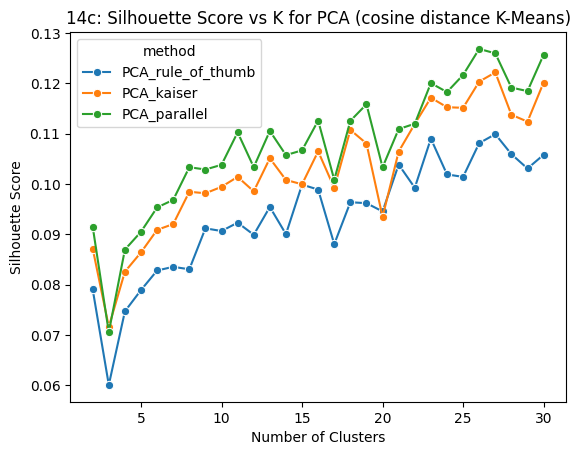

In [ ]:
# CONSISTENZA NEI COLORI!!!
filtered_df = all_results_faiss_df[all_results_faiss_df['method'].str.contains('PCA', case=False, na=False)]
# Create the line plot
sns.lineplot(filtered_df, x="n_clusters", y="silhouette_score", hue="method", marker="o", palette=color_dict)

# Add labels and title
plt.title("14c: Silhouette Score vs K for PCA (cosine distance K-Means)")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

# Display the plot
plt.show()

In [ ]:
#mettere il grafico aziendale per confronto

In [10]:
# Group by 'method' and find the index of the row with the highest 'silhouette score'
idx = all_results_faiss_df.groupby('method')['silhouette_score'].idxmax()

# Use the indices to filter the DataFrame
highest_silhouette_df = all_results_faiss_df.loc[idx]

# Display the result
print(highest_silhouette_df)


# INSERIRLO NELLA TESI?

     n_clusters  silhouette_score             method
54           27          0.122223         PCA_kaiser
86           30          0.128290       PCA_parallel
25           27          0.109869  PCA_rule_of_thumb
147           4          0.396635    UMAP_clustering
120           6          0.611187        UMAP_cosine
88            3          0.603775     UMAP_euclidean


DataFrame: PCA_kaiser, n_clusters = 27, Avg silhouette_score: 0.12222251494114181


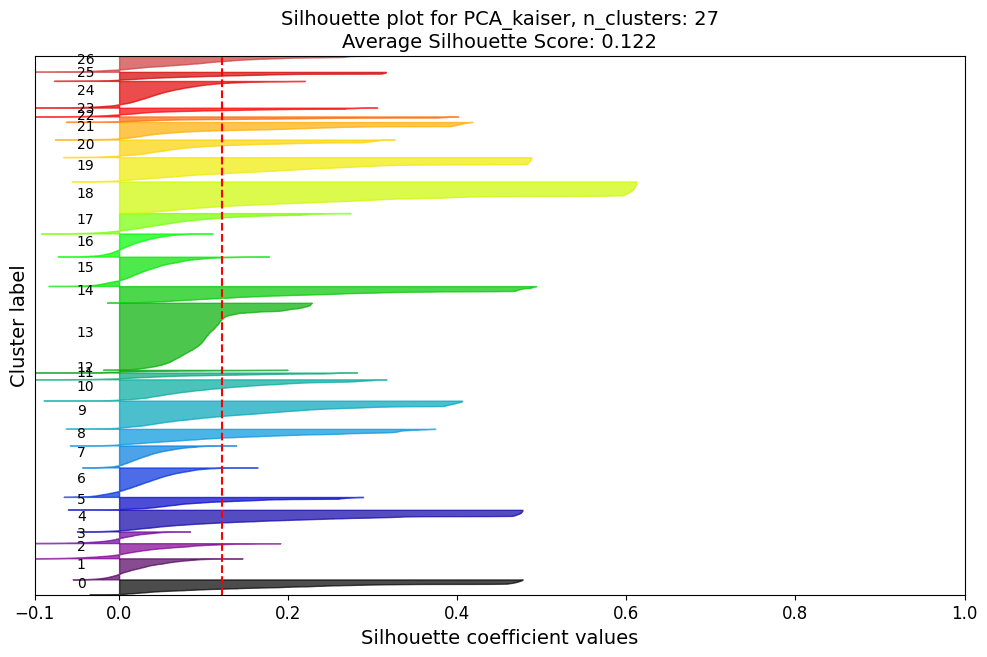

DataFrame: PCA_parallel, n_clusters = 30, Avg silhouette_score: 0.12828961441411535


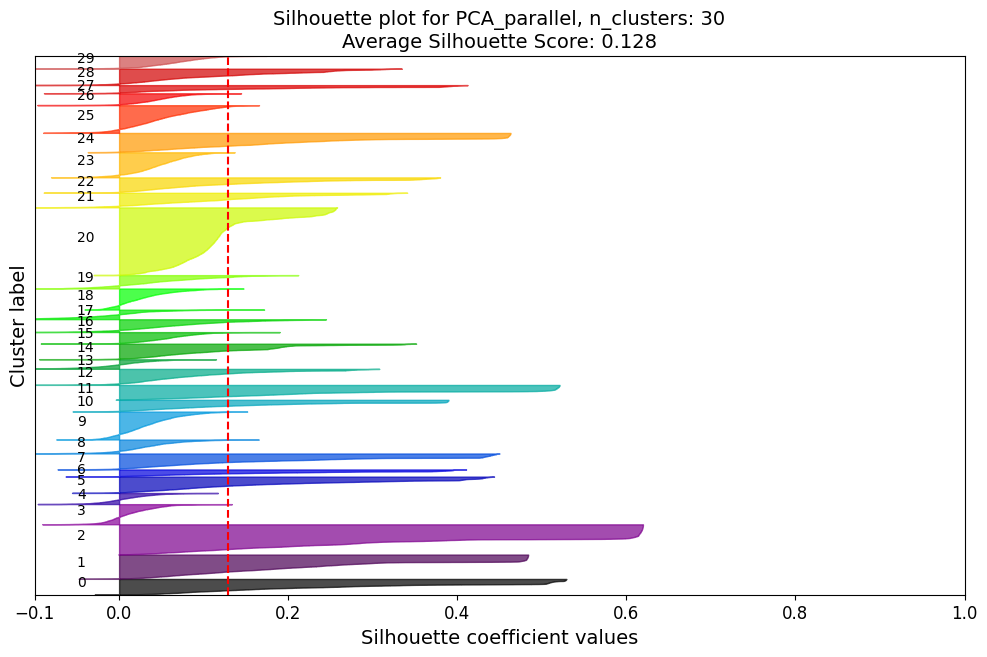

DataFrame: PCA_rule_of_thumb, n_clusters = 27, Avg silhouette_score: 0.10986919900500805


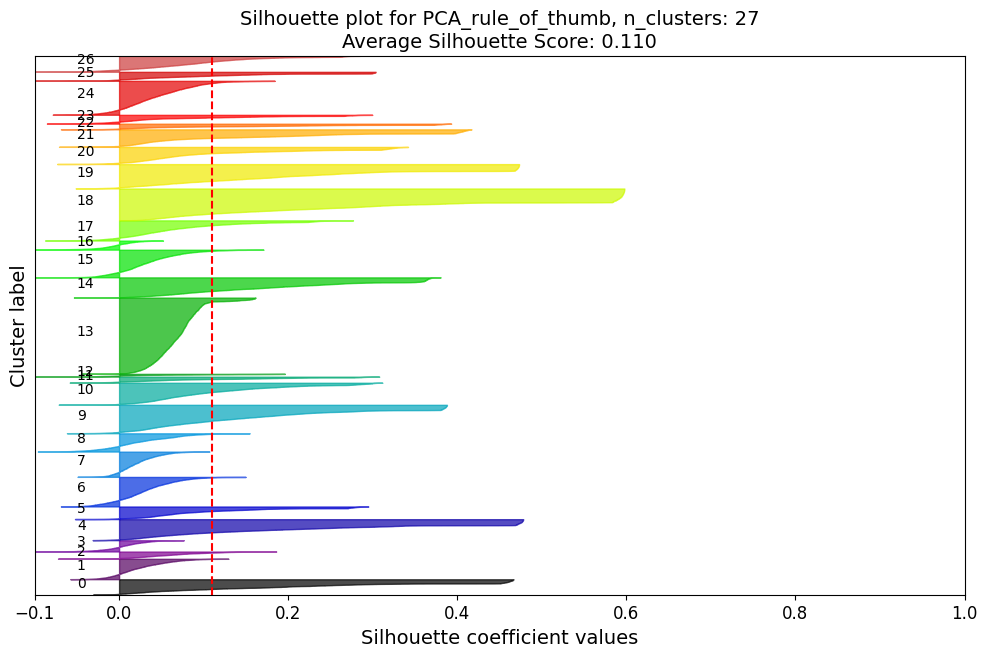

DataFrame: UMAP_clustering, n_clusters = 4, Avg silhouette_score: 0.39663505433517027


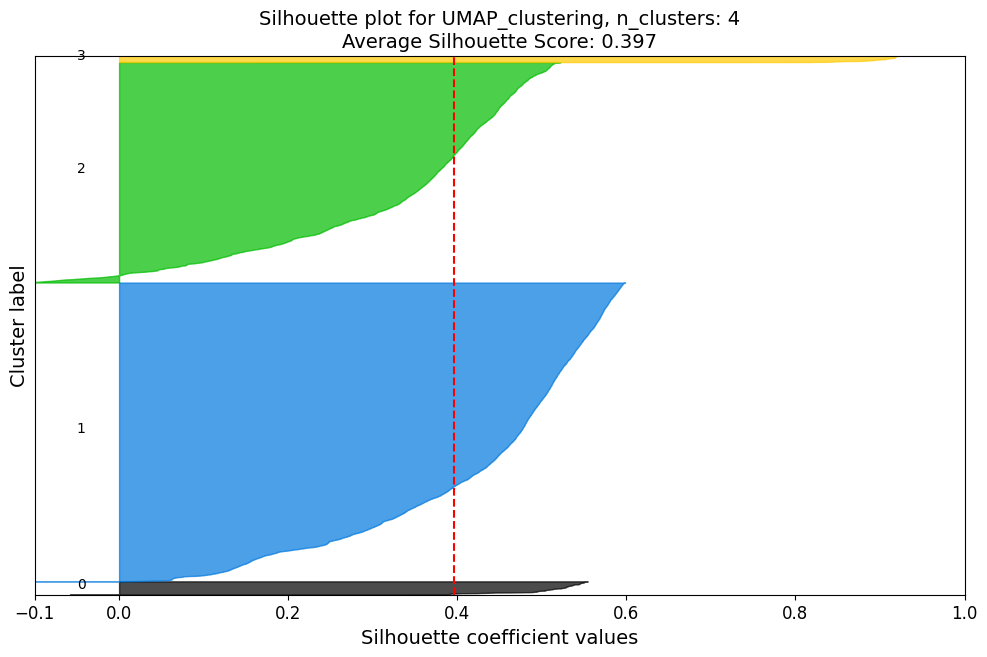

DataFrame: UMAP_cosine, n_clusters = 6, Avg silhouette_score: 0.6111870109900355


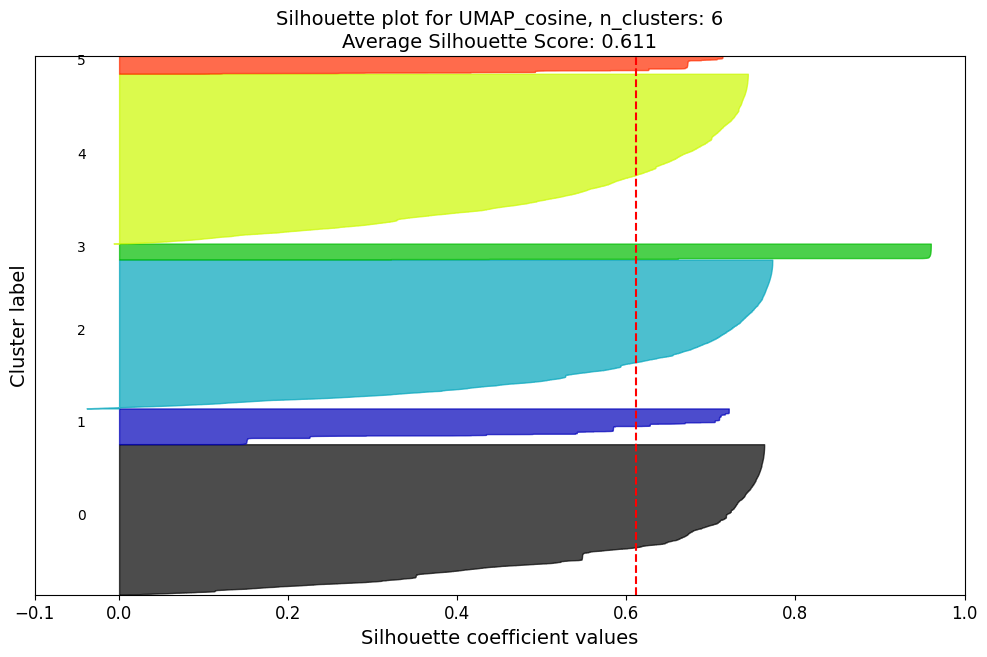

DataFrame: UMAP_euclidean, n_clusters = 3, Avg silhouette_score: 0.6037751617252565


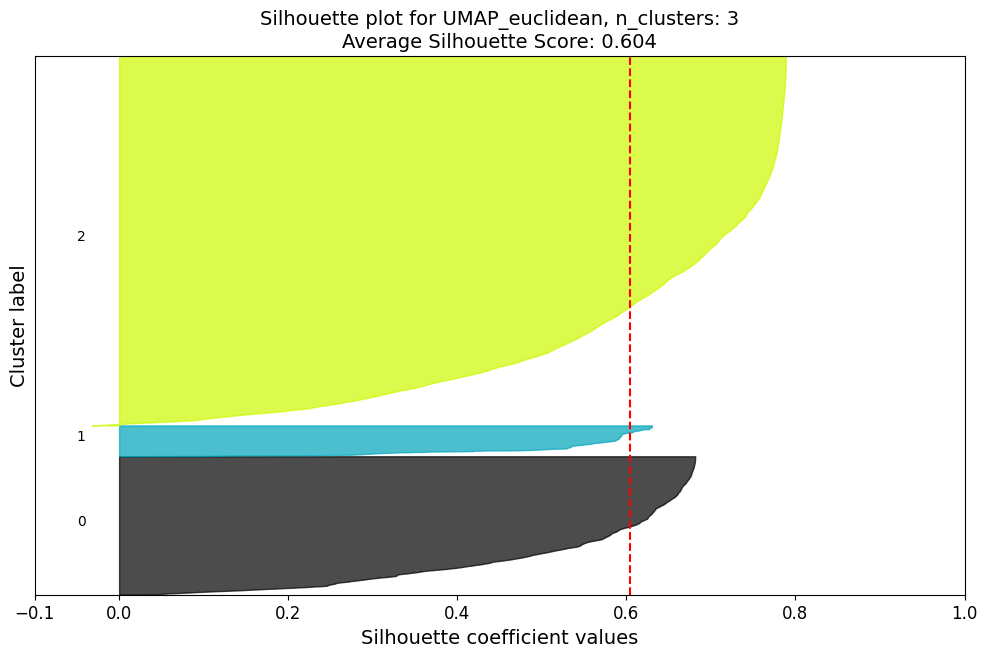

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score, silhouette_samples
import faiss

# Assuming dataframes dictionary is already defined and populated
dataframes_normalized = {}

dataframes = {
    "PCA_rule_of_thumb": PCA_rule_of_thumb,
    "PCA_kaiser": PCA_kaiser,
    "PCA_parallel": PCA_parallel,
    "UMAP_euclidean": UMAP_euclidean,
    "UMAP_cosine": UMAP_cosine,
    "UMAP_clustering": UMAP_clustering
}

fontsize = 14

for name, df in dataframes.items():
    dataframes[name] = df.drop(columns=["user_uid", "original_labels"])
    dataframes_normalized[name] = normalize(dataframes[name], norm='l2', axis=1)

# Iterate over rows in highest_silhouette_df
for _, row in highest_silhouette_df.iterrows():
    n_clusters = int(row['n_clusters'])
    X_name = row['method']
    X = dataframes_normalized[X_name]
    d = X.shape[1]  # Dimension of the data

    # Create a single subplot
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(12, 7)

    # Silhouette plot configuration
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize FAISS KMeans
    clusterer = faiss.Kmeans(d=d, k=n_clusters, niter=20, spherical=True, seed=42)

    # Train the clusterer
    clusterer.train(X)

    # Assign cluster labels
    _, cluster_labels = clusterer.index.search(X, 1)
    cluster_labels = cluster_labels.flatten()  # Convert to 1D array

    # Compute silhouette scores
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(f"DataFrame: {X_name}, n_clusters = {n_clusters}, Avg silhouette_score: {silhouette_avg}")

    sample_silhouette_values = silhouette_samples(X, cluster_labels)


    y_lower = 10
    for i in range(n_clusters):
        # Sort and aggregate silhouette scores for cluster i
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label clusters
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title(f"Silhouette plot for {X_name}, n_clusters: {n_clusters}\nAverage Silhouette Score: {silhouette_avg:.3f}",fontsize=fontsize)
    ax1.set_xlabel("Silhouette coefficient values",fontsize=fontsize)
    ax1.set_ylabel("Cluster label",fontsize=fontsize)
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.tick_params(axis='both', labelsize=12)
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.show()
